[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/luleu96/GenAIinDD_Exercises/blob/work/Exercises/Exercise_3/Importance_Sampling_new.ipynb)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
# the true data distribution -  a bimodal gaussian distribution
def true_distribution(x):
    return 0.3 * stats.norm.pdf(x, -2, 1) + 0.7 * stats.norm.pdf(x, 2, 1.5)

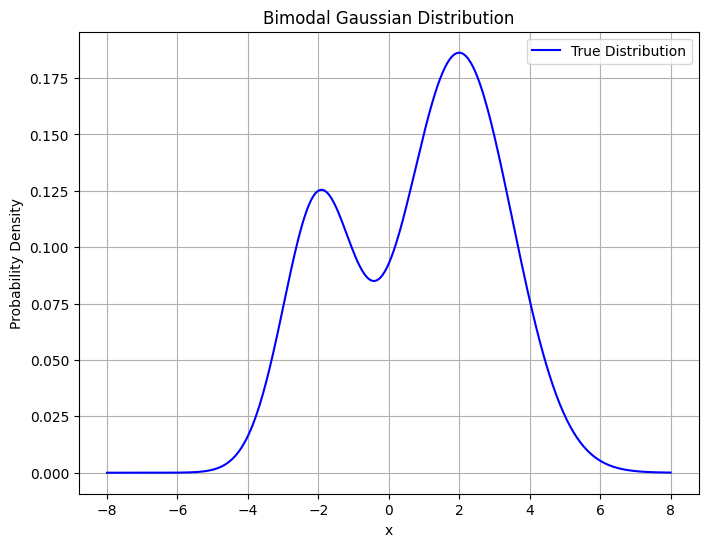

In [4]:
# Generate x values for plotting
x_values = np.linspace(-8, 8, 500)
y_values = true_distribution(x_values)

# Plot the distribution
plt.figure(figsize=(8, 6))
plt.plot(x_values, y_values, label="True Distribution", color="blue")
plt.title("Bimodal Gaussian Distribution")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.grid(True)
plt.legend()
plt.show()

In [6]:
# proposal distribution to sample from
def proposal_distribution(x):
    return stats.norm.pdf(x, 0, 3)

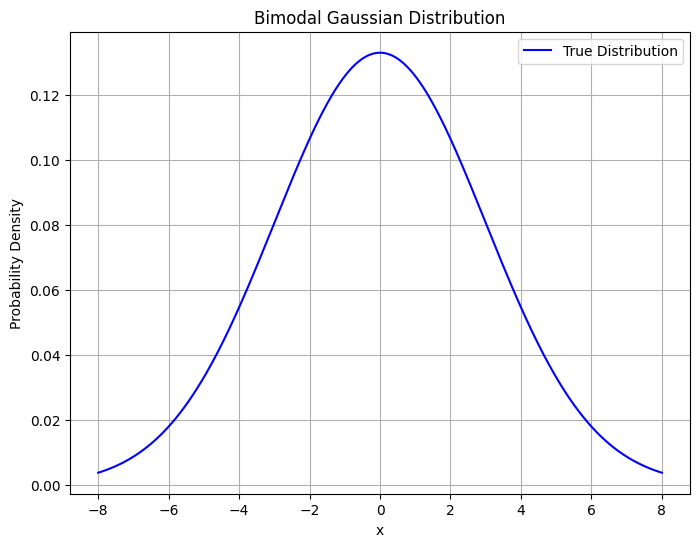

In [5]:
# Generate x values for plotting
x_values = np.linspace(-8, 8, 500)
y_values = proposal_distribution(x_values)

# Plot the distribution
plt.figure(figsize=(8, 6))
plt.plot(x_values, y_values, label="True Distribution", color="blue")
plt.title("Bimodal Gaussian Distribution")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Estimate the expected value of the true distribution using importance sampling
def estimate_expectation(n_samples=10000):

    # Sample from proposal distribution (easier to sample from)
    samples = np.random.normal(0, 3, n_samples)

    # Calculate importance weights
    weights = true_distribution(samples) / proposal_distribution(samples)

    # Normalize weights
    weights = weights / np.sum(weights)

    # Calculate weighted mean and effective sample size
    weighted_mean = np.sum(weights * samples)
    effective_sample_size = 1 / np.sum(weights ** 2)

    return weighted_mean, effective_sample_size

# Compute weighted kernel density estimation

def weighted_kde(samples, weights, x_eval):

    kernel = stats.gaussian_kde(samples, weights=weights * len(weights))
    return kernel(x_eval)

In [8]:
sample_sizes = [100, 1000, 10000]

print("Importance Sampling Results:")
print("-" * 50)
for n in sample_sizes:
    mean, eff_size = estimate_expectation(n)
    print(f"\nNumber of samples: {n}")
    print(f"Estimated mean: {mean:.4f}")
    print(f"Effective sample size: {eff_size:.1f}")

Importance Sampling Results:
--------------------------------------------------

Number of samples: 100
Estimated mean: 0.7031
Effective sample size: 80.1

Number of samples: 1000
Estimated mean: 0.8038
Effective sample size: 787.5

Number of samples: 10000
Estimated mean: 0.8074
Effective sample size: 7910.9


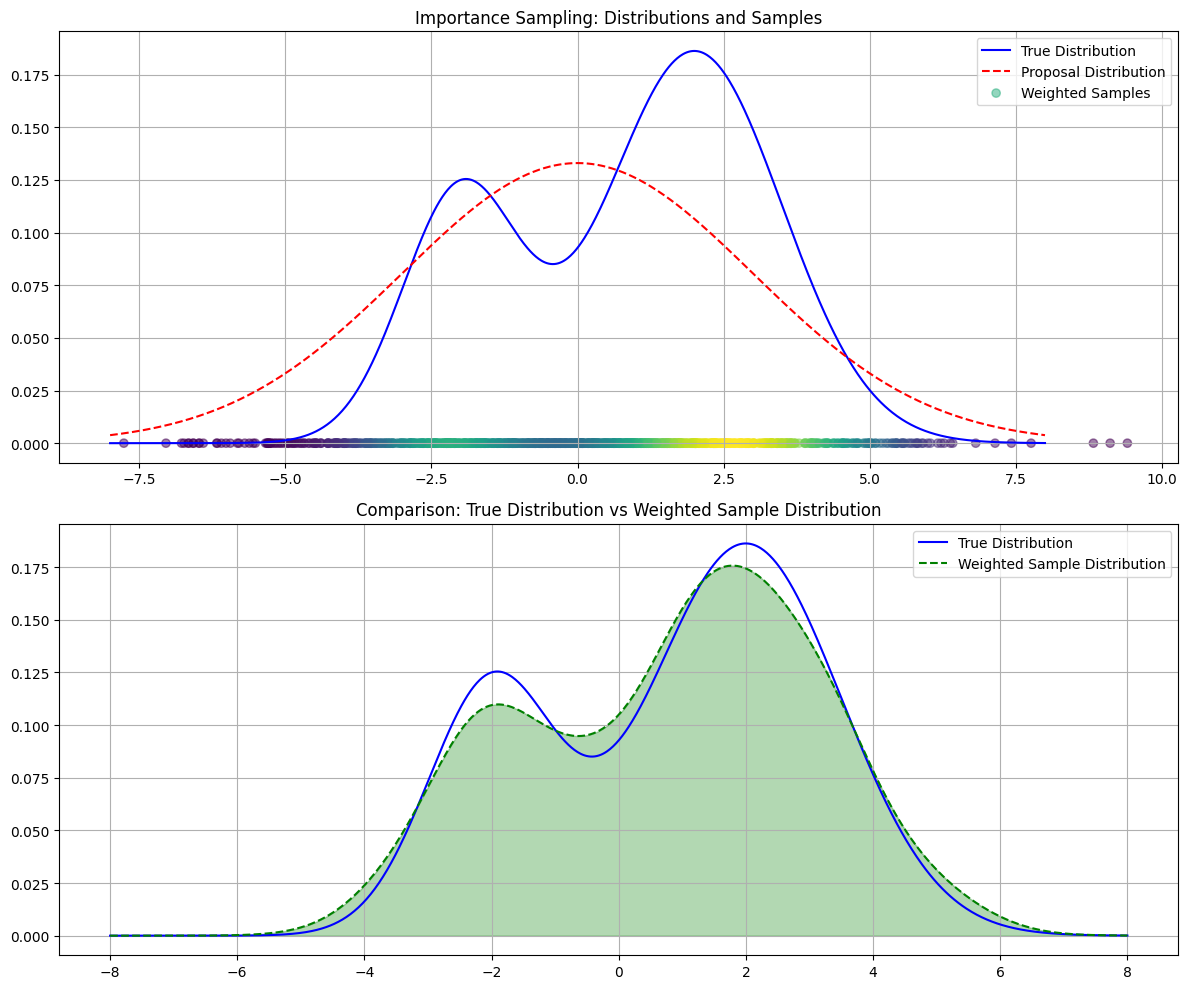

In [9]:
def visualize_sampling():
    x = np.linspace(-8, 8, 1000)

    # Generate samples and weights
    samples = np.random.normal(0, 3, 1000)
    weights = true_distribution(samples) / proposal_distribution(samples)
    weights = weights / np.sum(weights)

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # First subplot: Distributions and samples
    ax1.plot(x, true_distribution(x), 'b-', label='True Distribution')
    ax1.plot(x, proposal_distribution(x), 'r--', label='Proposal Distribution')
    ax1.scatter(samples, np.zeros_like(samples),
               c=weights, cmap='viridis',
               alpha=0.5, label='Weighted Samples')
    ax1.set_title('Importance Sampling: Distributions and Samples')
    ax1.legend()
    ax1.grid(True)

    # Second subplot: Compare true distribution with weighted KDE
    weighted_density = weighted_kde(samples, weights, x)
    ax2.plot(x, true_distribution(x), 'b-', label='True Distribution')
    ax2.plot(x, weighted_density, 'g--', label='Weighted Sample Distribution')
    ax2.fill_between(x, weighted_density, alpha=0.3, color='green')
    ax2.set_title('Comparison: True Distribution vs Weighted Sample Distribution')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()
visualize_sampling()